## Class 7: Different ways to select data

Last class:
- Introduced `.groupby()` and `.loc[]`
- Started talking about visualizing data

This class:
- How to identify rows by "index"
- Subsetting rows (and columns) using `.loc[]`
- Reviewing `.groupby()`
- Creating simple plots

We will use our class survey data to keep things simple

In [1]:
import pandas as pd

class_data = pd.read_csv("ggr274_survey.csv")
class_data.head()

,id,year,specialist_major,drink_type,cups_per_week,favourite_season,pets_num,pets_type,commute_mode,commute_time,intersection,city
0,1,3.0,Economics,Tea,5,Fall,0,NaN,Walking/Rolling,30,King and Spadina,Toronto
1,2,3.0,Biodiversity and Conservation Biology,Tea,4,Summer,0,NaN,Walking/Rolling,15,Bay Street and Wellesley Street,Toronto
2,3,2.0,Finance and Economics Specialist,Coffee,2,Summer,3,Dog;,Walking/Rolling,10,Spadina Avenue & Harbour Street,Toronto
3,4,2.0,B.M. Violin performance,Coffee,12,Summer,0,NaN,Subway,60,Major Mackenzie & Hwy 7,Toronto
4,5,2.0,Sociology,Tea,3,Fall,0,NaN,Walking/Rolling,15,Bay Street & Bloor Street,Toronto


### Index

We use the term "index" in a particular way with Pandas DataFrames. It is used to identify rows in the table.

By default the index is a range starting at 0. You can see it as the unlabeled left-most column above. 

It is also an attribute of the DataFrame

In [2]:
class_data.index

RangeIndex(start=0, stop=62, step=1)

You can change the index by setting it to a different column.  Notice that how the view of the data frame changes.



In [8]:
class_data_id = class_data.set_index("id")

class_data_id.head()

,year,specialist_major,drink_type,cups_per_week,favourite_season,pets_num,pets_type,commute_mode,commute_time,intersection,city
id,,,,,,,,,,,
1,3.0,Economics,Tea,5,Fall,0,NaN,Walking/Rolling,30,King and Spadina,Toronto
2,3.0,Biodiversity and Conservation Biology,Tea,4,Summer,0,NaN,Walking/Rolling,15,Bay Street and Wellesley Street,Toronto
3,2.0,Finance and Economics Specialist,Coffee,2,Summer,3,Dog;,Walking/Rolling,10,Spadina Avenue & Harbour Street,Toronto
4,2.0,B.M. Violin performance,Coffee,12,Summer,0,NaN,Subway,60,Major Mackenzie & Hwy 7,Toronto
5,2.0,Sociology,Tea,3,Fall,0,NaN,Walking/Rolling,15,Bay Street & Bloor Street,Toronto


In [4]:
# Now the index is defined as a list

class_data_id.index

Index([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18,
       19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36,
       37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54,
       55, 56, 57, 58, 59, 60, 61, 62],
      dtype='int64', name='id')

We could continue working with our new index, but since we are not often going to redefine the index in this class, we will keep it simple and go back to our default state. The DataFrame `class_data` hasn't changed.

The reason to talk about a DataFrame's index is because the way we select rows is based on the index. Before we jump into that, let's quickly review how we select columns from the DataFrame


In [5]:
class_data.head()

,id,year,specialist_major,drink_type,cups_per_week,favourite_season,pets_num,pets_type,commute_mode,commute_time,intersection,city
0,1,3.0,Economics,Tea,5,Fall,0,NaN,Walking/Rolling,30,King and Spadina,Toronto
1,2,3.0,Biodiversity and Conservation Biology,Tea,4,Summer,0,NaN,Walking/Rolling,15,Bay Street and Wellesley Street,Toronto
2,3,2.0,Finance and Economics Specialist,Coffee,2,Summer,3,Dog;,Walking/Rolling,10,Spadina Avenue & Harbour Street,Toronto
3,4,2.0,B.M. Violin performance,Coffee,12,Summer,0,NaN,Subway,60,Major Mackenzie & Hwy 7,Toronto
4,5,2.0,Sociology,Tea,3,Fall,0,NaN,Walking/Rolling,15,Bay Street & Bloor Street,Toronto


In [9]:
# recall how we select columns from a DataFrame

# select one column
class_spec = class_data["specialist_major"]
print(class_spec)

# what data type do we get as a result?
print(type(class_spec))


0                                Economics 
1     Biodiversity and Conservation Biology
2         Finance and Economics Specialist 
3                   B.M. Violin performance
4                                 Sociology
                      ...                  
57                   Finance and Economics 
58                        Civil Engineering
59                               Management
60                                   Rotman
61                                Sociology
Name: specialist_major, Length: 62, dtype: object
<class 'pandas.core.series.Series'>


In [10]:
# also notice that a Series has an index

class_spec.index

RangeIndex(start=0, stop=62, step=1)

In [11]:
# select multiple columns
class_data[["specialist_major", "commute_mode"]]

,specialist_major,commute_mode
0,Economics,Walking/Rolling
1,Biodiversity and Conservation Biology,Walking/Rolling
2,Finance and Economics Specialist,Walking/Rolling
3,B.M. Violin performance,Subway
4,Sociology,Walking/Rolling
...,...,...
57,Finance and Economics,Walking/Rolling
58,Civil Engineering,Bicycle/Scooter
59,Management,Walking/Rolling
60,Rotman,Walking/Rolling


### Selecting rows

The `.loc[]` accessor allows us to do a similar selection for rows. Here is how we select a single row by its index.

What data type do we get?

In [12]:
class_row = class_data.loc[2]

print(class_row)

print(type(class_row))

id                                                  3
year                                              2.0
specialist_major    Finance and Economics Specialist 
drink_type                                     Coffee
cups_per_week                                       2
favourite_season                               Summer
pets_num                                            3
pets_type                                        Dog;
commute_mode                          Walking/Rolling
commute_time                                       10
intersection          Spadina Avenue & Harbour Street
city                                         Toronto 
Name: 2, dtype: object
<class 'pandas.core.series.Series'>


Wait, that's a Series?  It doesn't really look like the Series we saw above. Is the first column really an index?

When we select a single row, we get a Series that is the values in the row.  The Index for this series is the column headings.

In [13]:

class_data.loc[2].index

Index(['id', 'year', 'specialist_major', 'drink_type', 'cups_per_week',
       'favourite_season', 'pets_num', 'pets_type', 'commute_mode',
       'commute_time', 'intersection', 'city'],
      dtype='object')

### Selecting multiple rows

There are several ways to do this. Similar to selecting columns, the result of selecting multiple rows is a DataFrame.


- We can use the same method as we did for selecting multiple columns by just passing in a list.
- If the index is a Range, then we can also use list slicing to select rows.

In [14]:
# select multiple rows

class_data.loc[[2, 4]]

,id,year,specialist_major,drink_type,cups_per_week,favourite_season,pets_num,pets_type,commute_mode,commute_time,intersection,city
2,3,2.0,Finance and Economics Specialist,Coffee,2,Summer,3,Dog;,Walking/Rolling,10,Spadina Avenue & Harbour Street,Toronto
4,5,2.0,Sociology,Tea,3,Fall,0,NaN,Walking/Rolling,15,Bay Street & Bloor Street,Toronto


In [15]:
# because the index in this case is a range, we can also use list slicing to get a range

class_data.loc[2:4]

,id,year,specialist_major,drink_type,cups_per_week,favourite_season,pets_num,pets_type,commute_mode,commute_time,intersection,city
2,3,2.0,Finance and Economics Specialist,Coffee,2,Summer,3,Dog;,Walking/Rolling,10,Spadina Avenue & Harbour Street,Toronto
3,4,2.0,B.M. Violin performance,Coffee,12,Summer,0,NaN,Subway,60,Major Mackenzie & Hwy 7,Toronto
4,5,2.0,Sociology,Tea,3,Fall,0,NaN,Walking/Rolling,15,Bay Street & Bloor Street,Toronto


### Using Boolean expressions to select rows

Once again this works the same as how we used these series on columns.

In [16]:
# use a boolean expression to select rows

# construct a boolean series that is true for the rows where "drink_type" is "Tea"
drink_type = class_data["drink_type"] == "Tea"

# Use the new series to subset the DataFrame
class_data.loc[drink_type]

,id,year,specialist_major,drink_type,cups_per_week,favourite_season,pets_num,pets_type,commute_mode,commute_time,intersection,city
0,1,3.0,Economics,Tea,5,Fall,0,NaN,Walking/Rolling,30,King and Spadina,Toronto
1,2,3.0,Biodiversity and Conservation Biology,Tea,4,Summer,0,NaN,Walking/Rolling,15,Bay Street and Wellesley Street,Toronto
4,5,2.0,Sociology,Tea,3,Fall,0,NaN,Walking/Rolling,15,Bay Street & Bloor Street,Toronto
6,7,4.0,Economics,Tea,6,Summer,1,Cat;,Walking/Rolling,30,King W and Spadina,Toronto
8,9,2.0,Economics,Tea,0,Summer,0,NaN,Walking/Rolling,25,Yonge Street & Bloor Street,Toronto
9,10,2.0,Linguistics,Tea,1,Fall,0,NaN,Bicycle/Scooter,10,Davenport Road & Avenue Road,Toronto
11,12,3.0,Human Geography,Tea,4,Fall,1,Cat;,Walking/Rolling,5,Bloor Street & St George Street,Toronto
12,13,3.0,Specialist in Finance and Econ,Tea,0,Fall,0,NaN,Walking/Rolling,25,Yonge and Bloor,Toronto
13,14,3.0,Economics,Tea,0,Spring,0,NaN,Bicycle/Scooter,20,Bloor and Sherborne,Toronto
17,18,2.0,Political Science,Tea,0,Fall,1,Dog;,Subway,50,Keele & Sheppard Avenue West,Toronto


## Back to .groupby()

What kinds of questions can we answer using `.groupby()`

Grouby statements follow a pattern:

`df.groupby("category")["column of interest"].aggregator()`

Where `df` is the dataframe, `"category"` is the field by which we want to divide up the data, `"column of interest"` is the column we want to do the math on, and `aggregator` is the function we want to apply. Let's look at a few examples:


Question 1: How many students prefer each season?


In [17]:
# There are two ways to do this that we've seen
# The first doesn't use .groupby, it uses .value_counts()

class_data["favourite_season"].value_counts()

favourite_season
Summer    24
Fall      21
Spring    12
Winter     5
Name: count, dtype: int64

In [18]:
# Using groupby

# We use size instead of count because count will give us a table with a count for each column (try it out)

class_data.groupby("favourite_season").size()

favourite_season
Fall      21
Spring    12
Summer    24
Winter     5
dtype: int64

Question 2:  Does commute time depend on mode of travel?

Let's think about this step by step:

 1. group by commute mode
 2. select the commute time column
 3. decide how to aggregate - In this case we want to find the mean commute time for a given mode of travel

In [19]:

class_data.groupby("commute_mode")["commute_time"].mean()

commute_mode
Bicycle/Scooter    15.000000
Car                45.000000
Subway             53.125000
Walking/Rolling    17.595238
Name: commute_time, dtype: float64

Question 3: For each season, how many people prefer each drink type?

This question is a little different because we want to compare two categories, so we will select both categories.  The first method gives us a kind of nested table which is a little hard to work with.  In the second approach we use "unstack" to get a DataFrame we can work with.  Before we get to the second example, we will clean up the data a bit too.

In [20]:

class_data.groupby(["favourite_season", "drink_type"]).size()

favourite_season  drink_type   
Fall              Coffee            9
                  Hot Chocolate     1
                  Hot chocolate     1
                  Juice             1
                  Tea               9
Spring            Coffee            3
                  Tea               9
Summer            Coffee           15
                  Hot Chocolate     1
                  Tea               8
Winter            Coffee            3
                  Matcha            1
                  hot chocolate     1
dtype: int64

In [21]:
# We really should clean up the drink_type column, so that we don't have multiple versions of "hot chocolate"

# Reassign the values in the "drink_type" column
# strip the white space from around the string
# set each one to lower case

class_data["drink_type"] = (
    class_data["drink_type"]
        .str.strip()
        .str.lower()
)

In [22]:
# If we want this as a table, then we need to unstack it

class_data.groupby(["favourite_season", "drink_type"]).size().unstack()

drink_type,coffee,hot chocolate,juice,matcha,tea
favourite_season,,,,,
Fall,9.0,2.0,1.0,NaN,9.0
Spring,3.0,NaN,NaN,NaN,9.0
Summer,15.0,1.0,NaN,NaN,8.0
Winter,3.0,1.0,NaN,1.0,NaN


<Axes: xlabel='favourite_season'>

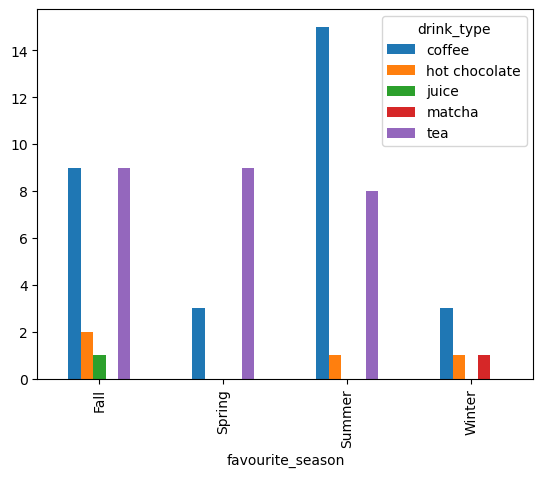

In [23]:
# Assign the result to a variable so we can plot it

counts = (
    class_data.groupby(["favourite_season", "drink_type"])
      .size()
      .unstack()
)

counts.plot(kind="bar")

But we probably want proportions rather than counts.  Let's take this step by step.

For each season we would like to know what proportion each drink makes up for the drinks for that season

$$
\text{proportion} =
\frac{\text{count of a single drink for that season}}
{\text{total number of drinks for that season}}
$$





**Step 1:** Given counts, we need to sum up the number of drinks for each season. 
- `axis=1` means go across the columns.  In other words we want the sum of the values in a row.

In [24]:
counts.sum(axis=1)

favourite_season
Fall      21.0
Spring    12.0
Summer    24.0
Winter     5.0
dtype: float64

**Step 2:** Now we can divide by each cell by its row total

`counts.div(counts.sum(axis=1), axis=0)`

Using the `.div()` aggregator method, divide every cell by the total for that's cell's row.  The total is given by `counts.sum(axis=1)`, and `axis=0` tells the aggregator to go across the rows. 
So each season’s row is divided by its own total.




In [25]:
proportions = counts.div(counts.sum(axis=1), axis=0)
print(proportions)



drink_type          coffee  hot chocolate     juice  matcha       tea
favourite_season                                                     
Fall              0.428571       0.095238  0.047619     NaN  0.428571
Spring            0.250000            NaN       NaN     NaN  0.750000
Summer            0.625000       0.041667       NaN     NaN  0.333333
Winter            0.600000       0.200000       NaN     0.2       NaN


<Axes: title={'center': 'Relationship between preferred season and favourite drink'}, xlabel='Favourite Season'>

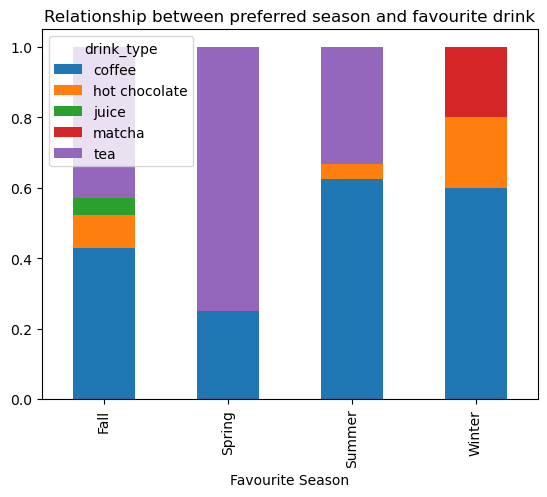

In [26]:
# Let's plot this one

proportions.plot(kind="bar", 
                 stacked=True, 
                 title="Relationship between preferred season and favourite drink" ,
                 xlabel="Favourite Season")